In [1]:
import os
os.chdir("../")
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ice_melting.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

In [3]:
def ic_fn(a, b, theta, x, y, epsilon, Lc=None):
    # a, b, x, y, are expected to be the physical coordinates
    
    if Lc is not None:
        # indicate that x, y are normalized coordinates
        x = x * Lc
        y = y * Lc

    # a, b, theta: scalars
    x_rot = x * jnp.cos(theta) + y * jnp.sin(theta)
    y_rot = -x * jnp.sin(theta) + y * jnp.cos(theta)

    term = jnp.sqrt((x_rot / a)**2 + (y_rot / b)**2) 
    scale = 2 * a * b / (a + b)
    dist = scale * (1.0 - term)

    u = jnp.tanh(dist / (jnp.sqrt(2) * epsilon)) # shape (H, W) or scalar
    return u

In [4]:
from models import get_model

key = jax.random.PRNGKey(0)
model_params = configs.model_params
model_skeleton = get_model(
    model_name=configs.model_name,
    key=key,
    **model_params,
)

# weight = "/root/autodl-tmp/tf-logs/ice_melting/ellipse/cvit/1230_25k_norar_causal_gradclip/model_epoch_25000.eqx"
weight = "/root/autodl-tmp/tf-logs/ice_melting/ellipse/cvit/baseline2/model_epoch_14500.eqx"
# weight = "/root/autodl-tmp/tf-logs/ice_melting/circle/1228baseline/model_epoch_25000.eqx"
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [5]:
# data_dir = configs.data_dir
data_dir = "./data/ice_melting/ellipse_refined_dt"
# data_dir = "./data/ice_melting/circle"
target_ts = [0.0, 1.0, 2.0, 3.0]
data_dir = data_dir
Lc = configs.Lc
Tc = configs.Tc
params = jnp.load(f"{data_dir}/initial_params.npy")
solutions = jnp.load(f"{data_dir}/solutions.npy") # (B, fem_steps, C, H, W)
fem_times = jnp.load(f"{data_dir}/times.npy") # (fem_steps,)
mesh_grids = jnp.load(f"{data_dir}/mesh_points.npy") # shape: (2, H, W)
idxs = jnp.array([jnp.argmin(jnp.abs(fem_times - t)) for t in target_ts]) # shape: (T,)
ref_sols = solutions[:, idxs, :, :, :]  # (B, T, C, H, W)
B, T, C, H, W = ref_sols.shape
us = ref_sols[:, 0, :, :, :]  # (B, C=1, H, W)
# us: (B, C=1, H, W)
# params: (B, P=3) --> (a, b, theta)
# mesh_grids: (2, H, W)
# target_ts: List of time steps to evaluate
# Lc, Tc: characteristic length and time scales
B, C, H, W = us.shape
meshx = mesh_grids[0]  # (H, W)
meshy = mesh_grids[1]  # (H, W)
x_coord = jnp.stack([meshx.reshape(-1), meshy.reshape(-1)], axis=-1) / Lc  # (H*W, 2)

def fwd_fn(carry, t):
    t_coord = jnp.full(
        (x_coord.shape[0], 1), t
    ) / Tc  # (H*W, 1)
    sol = jax.vmap(
        model, in_axes=(0, None, None)
    )(us, x_coord, t_coord)  # (B, H*W, C=1)
    return carry, sol

_, solutions_pred = jax.lax.scan(
    fwd_fn,
    None,
    fem_times,
)  # sols: (T, B, H*W, C=1)
# T, B, H*W, C=1 --> B, T, C, H, W
# solutions_pred = solutions_pred.transpose(1, 0, 3, 2).reshape(B, len(fem_times), C, H, W)
solutions_pred = rearrange(solutions_pred, "t b (h w) c -> b t c h w", h=int(H), w=int(W))

sols = solutions_pred[:, idxs, :, :, :]


Total relative L2 error: 0.020047


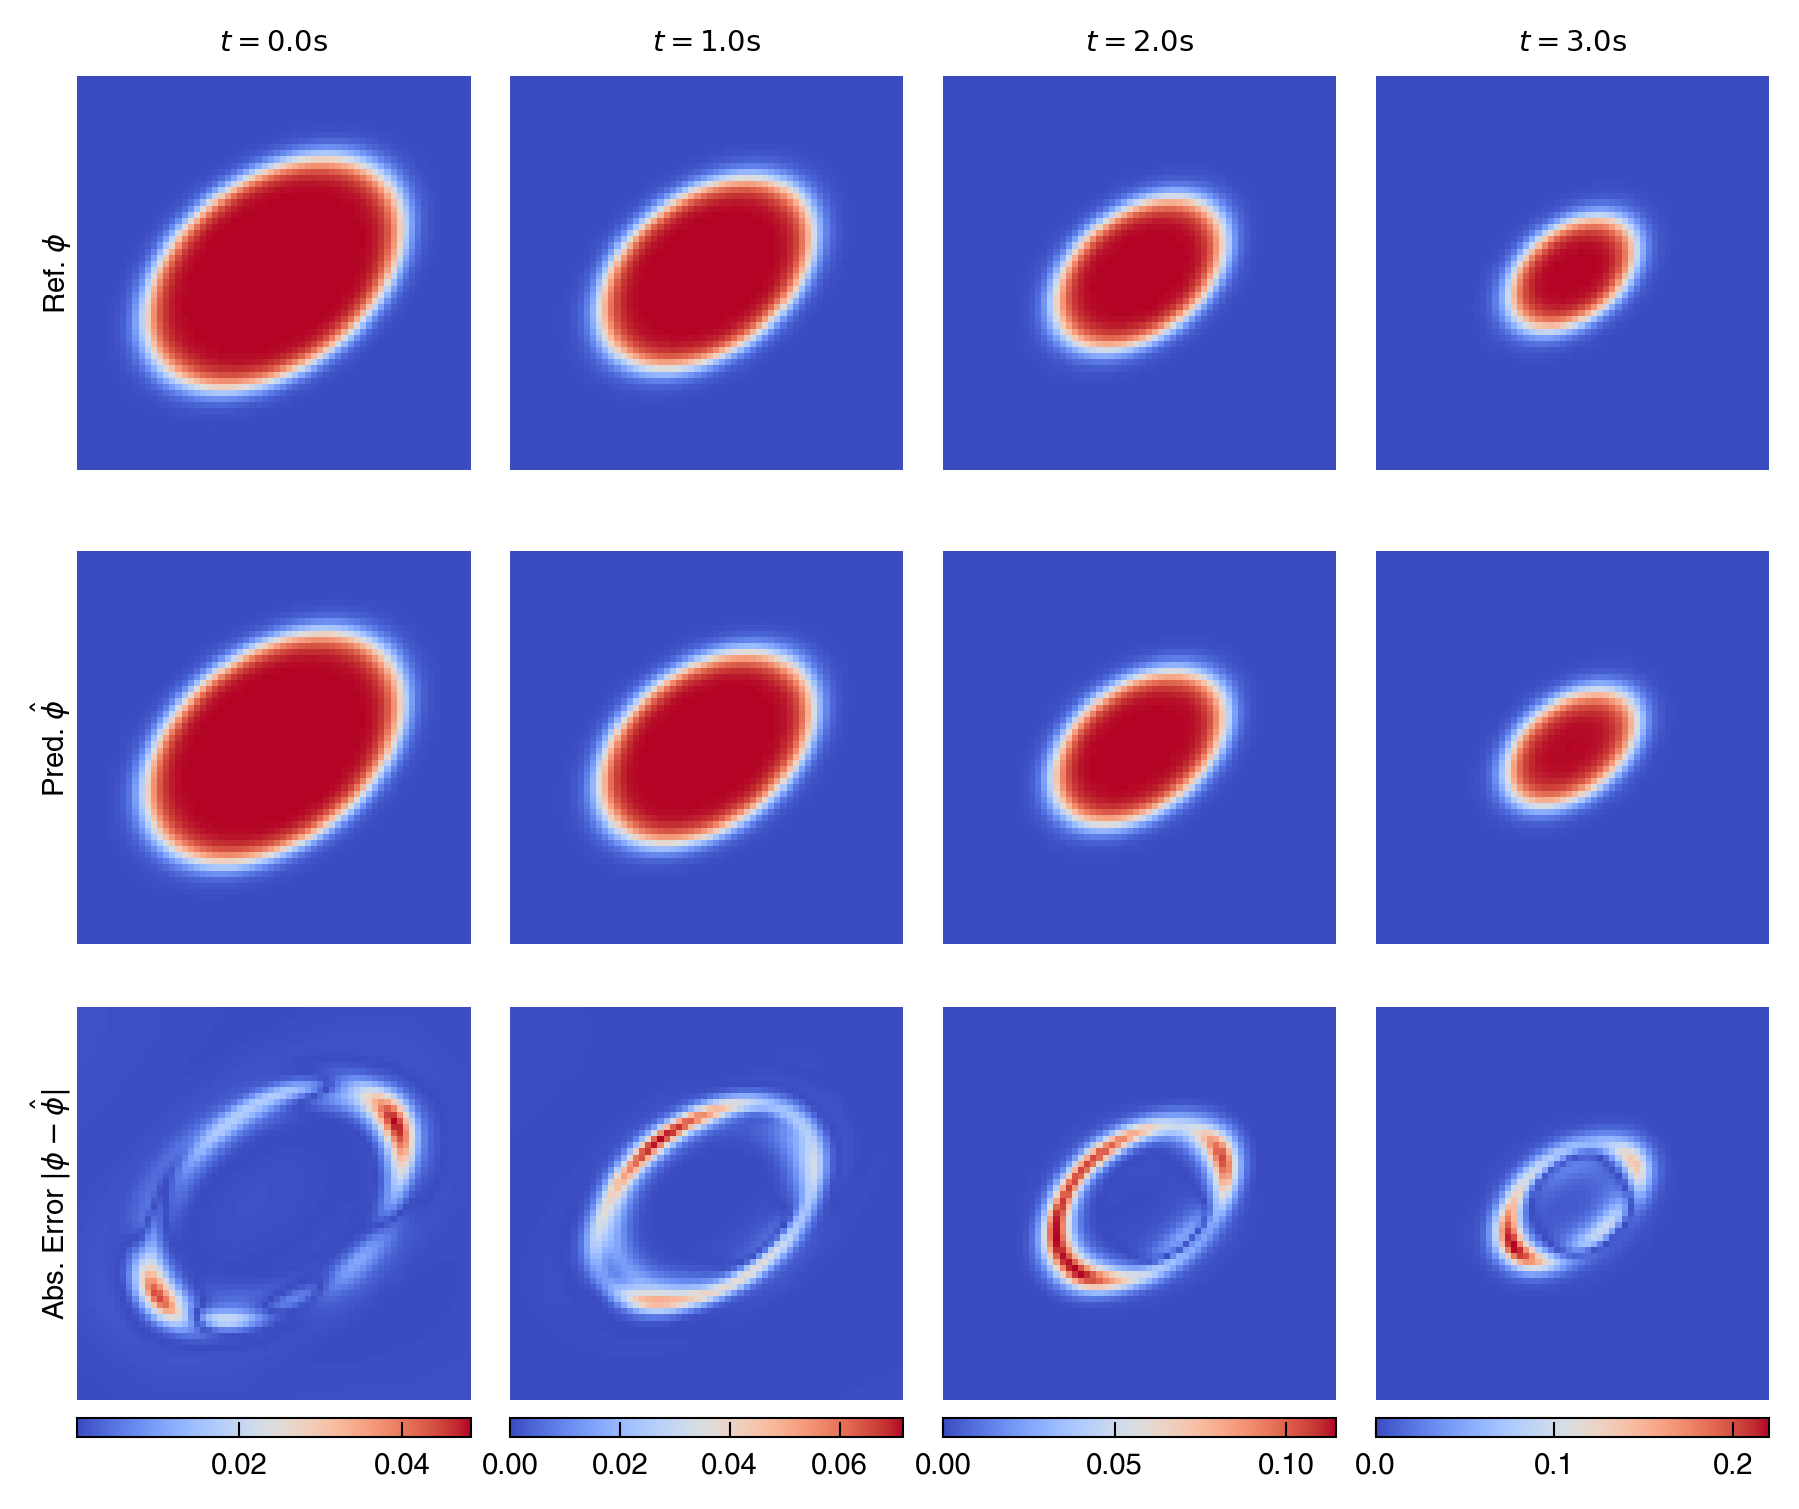

In [6]:
batch_th = 4
channel_th = 0  # only evaluate the first channel
fig, axes = plt.subplots(3, len(target_ts), figsize=(1.5 * len(target_ts), 5), subplot_kw={
    "aspect": "equal",
})
for i, tic in enumerate(target_ts):
    # plot reference
    ax = axes[0, i]
    ax.set_axis_off()
    ax.pcolormesh(
        meshx, meshy, 
        ref_sols[batch_th, i, channel_th, :, :], 
        cmap="coolwarm", shading="auto", rasterized=True,
        vmin=-1.0, vmax=1.0,
    )
    if i == 0:
        ax.text(-0.01, 0.5, r"Ref. $\phi$", 
                rotation=90, va="center", ha="right", transform=ax.transAxes
        )
    
    ax.text(0.5, 1.05, fr"$t={tic:.1f}\mathrm{{s}}$",
            va="bottom", ha="center", transform=ax.transAxes)
    
    ax = axes[1, i]
    ax.set_axis_off()
    ax.pcolormesh(
        meshx, meshy, 
        sols[batch_th, i, channel_th, :, :], 
        cmap="coolwarm", shading="auto", rasterized=True,
        vmin=-1.0, vmax=1.0,
    )
    if i == 0:
        ax.text(-0.01, 0.5, r"Pred. $\hat{\phi}$", 
                rotation=90, va="center", ha="right", transform=ax.transAxes
        )

    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(
        ref_sols[batch_th, i, channel_th, :, :] - sols[batch_th, i, channel_th, :, :]
    )
    diff_cont = ax.pcolormesh(
        meshx, meshy,
        diff,
        cmap="coolwarm", shading="auto", rasterized=True
    )
    if i == 0:
        ax.text(-0.01, 0.5, r"Abs. Error $|\phi - \hat{\phi}|$", 
                rotation=90, va="center", ha="right", transform=ax.transAxes
        )

    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04,
        orientation="horizontal"
    )

# total_l2 = jnp.linalg.norm(
#     ref_sols - sols, axis=(1, 3, 4)
# ) / jnp.linalg.norm(
#     ref_sols, axis=(1, 3, 4)
# )  # shape: (B, C)
total_l2 = jnp.sqrt(
    jnp.sum((ref_sols - sols) ** 2, axis=(1, 3, 4))
) / jnp.sqrt(
    jnp.sum(ref_sols ** 2, axis=(1, 3, 4))
)
total_l2 = jnp.mean(total_l2)
fig.subplots_adjust(
    left=0.03, right=0.97, top=0.95, bottom=0.03, hspace=0.1, wspace=0.1
)
print(f"Total relative L2 error: {total_l2:.6f}")

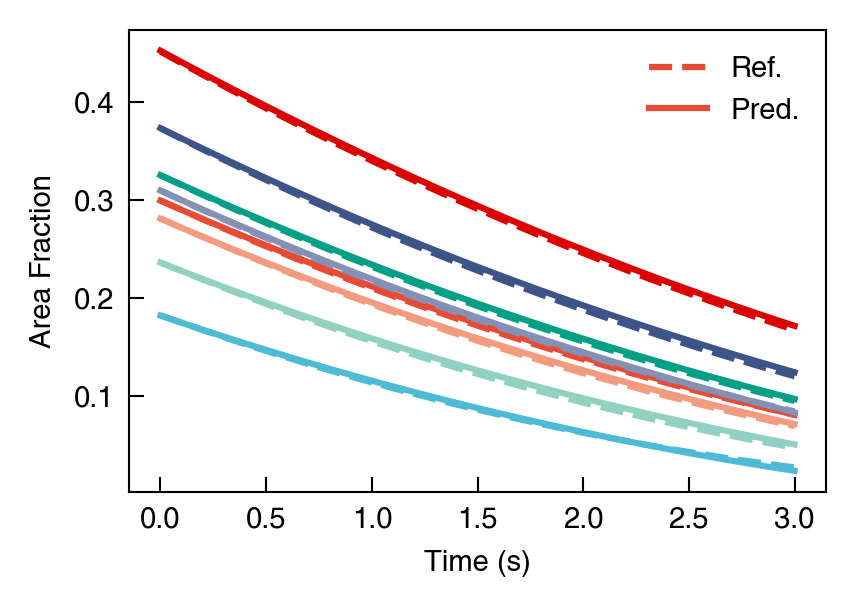

In [7]:
# area fraction

def compute_area_frac(sol):
    # sol shape: (..., H, W)
    area_frac = jnp.mean((sol + 1.0) / 2.0, axis=(-2, -1))
    return area_frac

area_fracs_ref = compute_area_frac(solutions)  # (B, T, 1)
area_fracs_pred = compute_area_frac(solutions_pred)  # (B, T, 1)
area_fracs_ref = area_fracs_ref.squeeze(-1)  # (B, T)
area_fracs_pred = area_fracs_pred.squeeze(-1)  # (B, T

fig, ax = plt.subplots(figsize=(3, 2))
for b in range(B):
    ax.plot(
        fem_times, area_fracs_ref[b, :], 
        color=f"C{b}", linestyle="--", label="Ref." if b == 0 else None
    )
    ax.plot(
        fem_times, area_fracs_pred[b, :], 
        color=f"C{b}", linestyle="-", label="Pred." if b == 0 else None
    )
ax.set_xlabel("Time (s)")
ax.set_ylabel("Area Fraction")
ax.legend()